# U-Net Medical Image Segmentation (With Dataset, Dice Loss & IoU)

## Beginner Setup (Virtual Environment + GPU)
Use these terminal commands once to create and activate a virtual environment:

```powershell
python -m venv .venv
.\.venv\Scripts\Activate.ps1
pip install --upgrade pip
pip install tensorflow opencv-python matplotlib numpy
```

If your TensorFlow build supports CUDA, the notebook will use GPU automatically.

In [1]:
import os
import random
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras import callbacks, layers, models

# Keep results reproducible for beginner experiments
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

# Enable GPU memory growth if GPU is available
gpus = tf.config.list_physical_devices("GPU")
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"GPU detected: {len(gpus)} device(s)")
else:
    print("GPU not detected. Training will run on CPU.")

I0000 00:00:1777077277.671558    6530 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1777077278.100044    6530 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI AVX_VNNI_INT8 AVX_NE_CONVERT FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1777077288.367260    6530 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


GPU not detected. Training will run on CPU.


W0000 00:00:1777077294.304800    6649 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1777077294.516577    6530 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


## Load Image & Mask Dataset

In [2]:
# =============================
# 1) PATH CONFIGURATION (EDIT LATER)
# =============================
BASE_DATA_DIR = "data"
TRAIN_IMAGE_DIR = os.path.join(BASE_DATA_DIR, "images")
TRAIN_MASK_DIR = os.path.join(BASE_DATA_DIR, "masks")
TEST_IMAGE_DIR = os.path.join(BASE_DATA_DIR, "test")

# Optional: set to a single test image path if needed
TEST_IMAGE_FILE = "results/3000.png"

# Optional: set to a folder if you also have test masks
TEST_MASK_DIR = "data/test_masks"  # Set to None if not available

# Final outputs (model + predicted masks + overlay images)
RESULT_IMAGE_DIR = os.path.join(BASE_DATA_DIR, "result")
MODEL_SAVE_PATH = os.path.join(RESULT_IMAGE_DIR, "unet_tumor_model.keras")

IMG_SIZE = 256
BATCH_SIZE = 4
EPOCHS = 10
VAL_SPLIT = 0.1
RANDOM_SEED = 42


def resolve_test_image_path(test_image_file):
    """Resolve a user-provided image path with common fallback locations."""
    if not test_image_file:
        return None

    candidates = [
        test_image_file,
        os.path.join(BASE_DATA_DIR, "result", os.path.basename(test_image_file)),
        os.path.join(BASE_DATA_DIR, "results", os.path.basename(test_image_file)),
    ]

    for candidate in candidates:
        if os.path.isfile(candidate):
            return candidate

    return None


def list_image_files(folder):
    """Return sorted image file names from a folder."""
    valid_ext = (".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff")
    if not os.path.isdir(folder):
        return []
    return sorted([f for f in os.listdir(folder) if f.lower().endswith(valid_ext)])


def validate_dataset_paths(image_dir, mask_dir, test_dir, result_dir):
    """Print path checks so updating paths later is easy and safe."""
    print("Train image path:", image_dir, "->", os.path.isdir(image_dir))
    print("Train mask path :", mask_dir, "->", os.path.isdir(mask_dir))
    print("Test image path :", test_dir, "->", os.path.isdir(test_dir))
    Path(result_dir).mkdir(parents=True, exist_ok=True)
    print("Result path     :", result_dir, "->", os.path.isdir(result_dir))


def read_grayscale_image(path, size):
    """Read image as grayscale and resize."""
    image = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if image is None:
        return None
    image = cv2.resize(image, (size, size))
    return image


def load_train_dataset(image_dir, mask_dir, img_size=256):
    """Load paired train images and masks using same file names."""
    image_files = list_image_files(image_dir)
    mask_files = set(list_image_files(mask_dir))

    images = []
    masks = []
    paired_files = []

    for file_name in image_files:
        # Only load pairs that exist in both image and mask folders
        if file_name not in mask_files:
            continue

        img_path = os.path.join(image_dir, file_name)
        mask_path = os.path.join(mask_dir, file_name)

        img = read_grayscale_image(img_path, img_size)
        mask = read_grayscale_image(mask_path, img_size)

        if img is None or mask is None:
            continue

        # Normalize image to [0, 1]
        img = img.astype(np.float32) / 255.0

        # Convert mask to strict binary: background=0, tumor=1
        mask = (mask > 127).astype(np.float32)

        images.append(img)
        masks.append(mask)
        paired_files.append(file_name)

    if len(images) == 0:
        raise ValueError(
            "No valid image-mask pairs found. Check TRAIN_IMAGE_DIR and TRAIN_MASK_DIR."
        )

    X = np.array(images, dtype=np.float32)[..., np.newaxis]
    y = np.array(masks, dtype=np.float32)[..., np.newaxis]

    return X, y, paired_files


validate_dataset_paths(TRAIN_IMAGE_DIR, TRAIN_MASK_DIR, TEST_IMAGE_DIR, RESULT_IMAGE_DIR)
X, y, paired_names = load_train_dataset(TRAIN_IMAGE_DIR, TRAIN_MASK_DIR, IMG_SIZE)

print("Loaded train pairs:", len(paired_names))
print("X shape:", X.shape)
print("y shape:", y.shape)

resolved_test_image = resolve_test_image_path(TEST_IMAGE_FILE)
print("Resolved TEST_IMAGE_FILE:", resolved_test_image)

test_files = list_image_files(TEST_IMAGE_DIR)
print("Available test images:", len(test_files))

Train image path: data/images -> True
Train mask path : data/masks -> True
Test image path : data/test -> True
Result path     : data/result -> True
Loaded train pairs: 1999
X shape: (1999, 256, 256, 1)
y shape: (1999, 256, 256, 1)
Resolved TEST_IMAGE_FILE: data/result/3000.png
Available test images: 1000


## Dice Loss & IoU Metric

In [3]:
def dice_coef(y_true, y_pred):
    """Dice score: higher is better (1.0 is perfect overlap)."""
    smooth = 1.0
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (2.0 * intersection + smooth) / (
        tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth
    )


def dice_loss(y_true, y_pred):
    """Dice loss: lower is better."""
    return 1.0 - dice_coef(y_true, y_pred)


def iou_metric(y_true, y_pred):
    """IoU after thresholding prediction at 0.5."""
    y_pred = tf.cast(y_pred > 0.5, tf.float32)
    intersection = tf.reduce_sum(y_true * y_pred)
    union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) - intersection
    return intersection / (union + 1e-7)

## U-Net Model

In [4]:
def conv_block(x, filters):
    x = layers.Conv2D(filters, (3, 3), padding="same", activation="relu")(x)
    x = layers.Conv2D(filters, (3, 3), padding="same", activation="relu")(x)
    return x


def build_unet(input_shape=(256, 256, 1), base_filters=32):
    """Beginner-friendly U-Net implementation."""
    inputs = layers.Input(shape=input_shape)

    c1 = conv_block(inputs, base_filters)
    p1 = layers.MaxPooling2D((2, 2))(c1)

    c2 = conv_block(p1, base_filters * 2)
    p2 = layers.MaxPooling2D((2, 2))(c2)

    c3 = conv_block(p2, base_filters * 4)
    p3 = layers.MaxPooling2D((2, 2))(c3)

    c4 = conv_block(p3, base_filters * 8)
    p4 = layers.MaxPooling2D((2, 2))(c4)

    bn = conv_block(p4, base_filters * 16)

    u1 = layers.UpSampling2D((2, 2))(bn)
    u1 = layers.Concatenate()([u1, c4])
    c5 = conv_block(u1, base_filters * 8)

    u2 = layers.UpSampling2D((2, 2))(c5)
    u2 = layers.Concatenate()([u2, c3])
    c6 = conv_block(u2, base_filters * 4)

    u3 = layers.UpSampling2D((2, 2))(c6)
    u3 = layers.Concatenate()([u3, c2])
    c7 = conv_block(u3, base_filters * 2)

    u4 = layers.UpSampling2D((2, 2))(c7)
    u4 = layers.Concatenate()([u4, c1])
    c8 = conv_block(u4, base_filters)

    outputs = layers.Conv2D(1, (1, 1), activation="sigmoid")(c8)

    return models.Model(inputs, outputs, name="UNet_TumorSegmentation")


model = build_unet(input_shape=(IMG_SIZE, IMG_SIZE, 1), base_filters=32)
model.summary()

Model: "UNet_TumorSegmentation"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │        320 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │      9,248 │ conv2d[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │     36,928 │ conv2d_2[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 64, 64,    │    147,584 │ conv2d_4[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 32, 32,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 32, 32,    │    295,168 │ max_pooling2d_2[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 32, 32,    │    590,080 │ conv2d_6[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 16, 16,    │          0 │ conv2d_7[0][0]    │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 16, 16,    │  1,180,160 │ max_pooling2d_3[… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 16, 16,    │  2,359,808 │ conv2d_8[0][0]    │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 32, 32,    │          0 │ conv2d_9[0][0]    │
│ (UpSampling2D)      │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 32, 32,    │          0 │ up_sampling2d[0]

 Total params: 7,846,081 (29.93 MB)

 Trainable params: 7,846,081 (29.93 MB)

 Non-trainable params: 0 (0.00 B)

## Compile Model

In [5]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=dice_loss,
    metrics=[dice_coef, iou_metric, "accuracy"],
)

print("Model compiled successfully.")

Model compiled successfully.


## Train Model

In [6]:
# =============================
# 2) TRAIN / VALIDATION SPLIT
# =============================
num_samples = len(X)
indices = np.arange(num_samples)
np.random.seed(RANDOM_SEED)
np.random.shuffle(indices)

X = X[indices]
y = y[indices]

val_size = max(1, int(num_samples * VAL_SPLIT))
if val_size >= num_samples:
    val_size = 1

X_val = X[:val_size]
y_val = y[:val_size]
X_train = X[val_size:]
y_train = y[val_size:]

print("Train set:", X_train.shape, y_train.shape)
print("Val set  :", X_val.shape, y_val.shape)

if len(X_train) == 0:
    raise ValueError("Training set is empty. Add more data or reduce VAL_SPLIT.")


def make_tf_dataset(images, masks, batch_size=4, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((images, masks))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(images), seed=RANDOM_SEED)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds


train_ds = make_tf_dataset(X_train, y_train, batch_size=BATCH_SIZE, shuffle=True)
val_ds = make_tf_dataset(X_val, y_val, batch_size=BATCH_SIZE, shuffle=False)


checkpoint_cb = callbacks.ModelCheckpoint(
    filepath=MODEL_SAVE_PATH,
    monitor="val_loss",
    save_best_only=True,
    verbose=1,
    mode="min",
)
early_stop_cb = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1,
    mode="min",
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[checkpoint_cb, early_stop_cb],
    verbose=1,
)

print("Best model saved at:", MODEL_SAVE_PATH)

Train set: (1800, 256, 256, 1) (1800, 256, 256, 1)
Val set  : (199, 256, 256, 1) (199, 256, 256, 1)
Epoch 1/10


E0000 00:00:1777077918.686630    6530 util.cc:131] oneDNN supports DT_INT32 only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.


450/450 ━━━━━━━━━━━━━━━━━━━━ 0s 285ms/step - accuracy: 0.7718 - dice_coef: 0.0132 - iou_metric: 0.0099 - loss: 0.9868
Epoch 1: val_loss improved from None to 0.99967, saving model to data/result/unet_tumor_model.keras

Epoch 1: finished saving model to data/result/unet_tumor_model.keras
450/450 ━━━━━━━━━━━━━━━━━━━━ 139s 296ms/step - accuracy: 0.9186 - dice_coef: 0.0045 - iou_metric: 0.0033 - loss: 0.9955 - val_accuracy: 0.9851 - val_dice_coef: 3.2852e-04 - val_iou_metric: 0.0000e+00 - val_loss: 0.9997
Epoch 2/10
450/450 ━━━━━━━━━━━━━━━━━━━━ 0s 297ms/step - accuracy: 0.9854 - dice_coef: 3.2233e-04 - iou_metric: 0.0000e+00 - loss: 0.9997
Epoch 2: val_loss improved from 0.99967 to 0.99967, saving model to data/result/unet_tumor_model.keras

Epoch 2: finished saving model to data/result/unet_tumor_model.keras
450/450 ━━━━━━━━━━━━━━━━━━━━ 138s 308ms/step - accuracy: 0.9852 - dice_coef: 3.1311e-04 - iou_metric: 0.0000e+00 - loss: 0.9997 - val_accuracy: 0.9851 - val_dice_coef: 3.2866e-04 - va

## Prediction & Output Visualization

Prediction images saved to: data/result


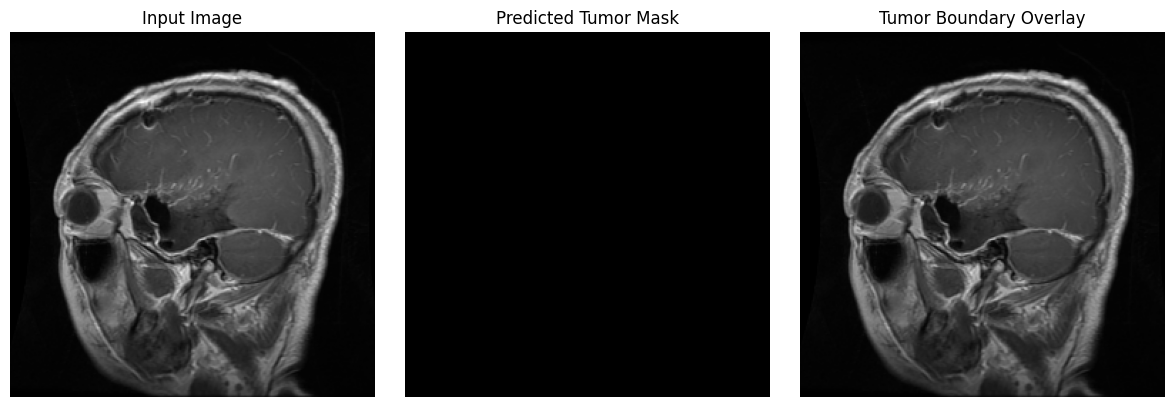

In [7]:
# =============================
# 3) TEST DATA PREDICTION + SAVE RESULT IMAGES
# =============================
def load_test_images(test_dir, img_size, test_image_path=None):
    if test_image_path and os.path.isfile(test_image_path):
        img = read_grayscale_image(test_image_path, img_size)
        if img is not None:
            img = img.astype(np.float32) / 255.0
            images = np.array([img], dtype=np.float32)[..., np.newaxis]
            return images, [os.path.basename(test_image_path)]

    file_names = list_image_files(test_dir)
    images = []
    valid_file_names = []
    for file_name in file_names:
        img_path = os.path.join(test_dir, file_name)
        img = read_grayscale_image(img_path, img_size)
        if img is None:
            continue
        img = img.astype(np.float32) / 255.0
        images.append(img)
        valid_file_names.append(file_name)

    if len(images) == 0:
        return np.array([]), []

    images = np.array(images, dtype=np.float32)[..., np.newaxis]
    return images, valid_file_names


def save_prediction_outputs(image_batch, pred_batch, file_names, result_dir):
    Path(result_dir).mkdir(parents=True, exist_ok=True)

    for i in range(len(pred_batch)):
        original = (image_batch[i].squeeze() * 255).astype(np.uint8)
        pred_mask = (pred_batch[i].squeeze() > 0.5).astype(np.uint8) * 255

        # Build a green contour overlay so tumor region is clear
        overlay = cv2.cvtColor(original, cv2.COLOR_GRAY2BGR)
        contours, _ = cv2.findContours(
            pred_mask.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
        )
        cv2.drawContours(overlay, contours, -1, (0, 255, 0), 2)

        name_stem = os.path.splitext(file_names[i])[0]
        mask_out = os.path.join(result_dir, f"{name_stem}_pred_mask.png")
        overlay_out = os.path.join(result_dir, f"{name_stem}_overlay.png")

        cv2.imwrite(mask_out, pred_mask)
        cv2.imwrite(overlay_out, overlay)

    print("Prediction images saved to:", result_dir)


test_images, test_names = load_test_images(TEST_IMAGE_DIR, IMG_SIZE, resolved_test_image)

# If no test folder images are present, use first 3 train images as a fallback demo
if len(test_images) == 0:
    print("No test images found. Using first 3 training images for demo prediction.")
    test_images = X[:3]
    test_names = [f"train_demo_{i}.png" for i in range(len(test_images))]

predictions = model.predict(test_images, verbose=0)
save_prediction_outputs(test_images, predictions, test_names, RESULT_IMAGE_DIR)

# Visualize one sample result
sample_idx = 0
sample_input = test_images[sample_idx].squeeze()
sample_pred = (predictions[sample_idx].squeeze() > 0.5).astype(np.uint8)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.title("Input Image")
plt.imshow(sample_input, cmap="gray")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.title("Predicted Tumor Mask")
plt.imshow(sample_pred, cmap="gray")
plt.axis("off")

overlay_rgb = cv2.cvtColor((sample_input * 255).astype(np.uint8), cv2.COLOR_GRAY2RGB)
contours, _ = cv2.findContours(
    (sample_pred * 255).astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
)
cv2.drawContours(overlay_rgb, contours, -1, (0, 255, 0), 2)

plt.subplot(1, 3, 3)
plt.title("Tumor Boundary Overlay")
plt.imshow(overlay_rgb)
plt.axis("off")
plt.tight_layout()
plt.show()

In [8]:
print('History keys:', list(history.history.keys()))
for key, values in history.history.items():
    print(key, '->', values[-1] if values else None)

print('Resolved test image:', resolved_test_image)
print('Test images shape:', test_images.shape)
print('Test names:', test_names[:5])


History keys: ['accuracy', 'dice_coef', 'iou_metric', 'loss', 'val_accuracy', 'val_dice_coef', 'val_iou_metric', 'val_loss']
accuracy -> 0.9852465987205505
dice_coef -> 0.0003114242572337389
iou_metric -> 0.0
loss -> 0.9996890425682068
val_accuracy -> 0.9850848913192749
val_dice_coef -> 0.0003286863793618977
val_iou_metric -> 0.0
val_loss -> 0.9996716380119324
Resolved test image: data/result/3000.png
Test images shape: (1, 256, 256, 1)
Test names: ['3000.png']


In [9]:
def load_test_dataset(image_dir, mask_dir, img_size=256, limit=None):
    image_files = list_image_files(image_dir)
    mask_files = set(list_image_files(mask_dir))

    images = []
    masks = []
    matched_files = []

    for file_name in image_files:
        if file_name not in mask_files:
            continue
        img_path = os.path.join(image_dir, file_name)
        mask_path = os.path.join(mask_dir, file_name)

        img = read_grayscale_image(img_path, img_size)
        mask = read_grayscale_image(mask_path, img_size)
        if img is None or mask is None:
            continue

        img = img.astype(np.float32) / 255.0
        mask = (mask > 127).astype(np.float32)

        images.append(img)
        masks.append(mask)
        matched_files.append(file_name)

        if limit is not None and len(images) >= limit:
            break

    if not images:
        return np.array([]), np.array([]), []

    X_test = np.array(images, dtype=np.float32)[..., np.newaxis]
    y_test = np.array(masks, dtype=np.float32)[..., np.newaxis]
    return X_test, y_test, matched_files


TEST_IMAGE_MASK_DIR = 'data/test_mask'
X_test_eval, y_test_eval, test_eval_names = load_test_dataset(TEST_IMAGE_DIR, TEST_IMAGE_MASK_DIR, IMG_SIZE)
print('Test eval pairs:', len(test_eval_names))
print('Test eval names sample:', test_eval_names[:5])

if len(test_eval_names) > 0:
    test_ds = tf.data.Dataset.from_tensor_slices((X_test_eval, y_test_eval)).batch(BATCH_SIZE)
    test_metrics = model.evaluate(test_ds, verbose=0)
    print('Test metric names:', model.metrics_names)
    print('Test metrics:', test_metrics)
else:
    print('No matching test-image/test-mask pairs found.')


Test eval pairs: 1000
Test eval names sample: ['2000.png', '2001.png', '2002.png', '2003.png', '2004.png']
Test metric names: ['loss', 'compile_metrics']
Test metrics: [0.9997527599334717, 0.0002472667256370187, 0.0, 0.9784098863601685]


In [10]:
if len(test_eval_names) > 0:
    test_ds = tf.data.Dataset.from_tensor_slices((X_test_eval, y_test_eval)).batch(BATCH_SIZE)
    test_metrics_dict = model.evaluate(test_ds, verbose=0, return_dict=True)
    print('Test metrics dict:', test_metrics_dict)


Test metrics dict: {'accuracy': 0.9784098863601685, 'dice_coef': 0.0002472667256370187, 'iou_metric': 0.0, 'loss': 0.9997527599334717}
